# Machine Learning — forecasting PM2.5 in central Paris for the next day (D+1)

**Goal:** every evening (day D), forecast for tomorrow (D+1):
1. the **daily mean of PM2.5** (a number, in µg/m³) → **regression**;
2. whether it will **exceed the WHO guideline of 15 µg/m³** (yes / no) → derived from the forecast value, evaluated as a **classification**.

**Plan:**
1. Build the features (what is known on the evening of day D)
2. Split the data in time: train / validation / test
3. Baseline: "tomorrow = today" (persistence)
4. Linear regression
5. Random Forest + hyperparameter tuning
6. Handling the imbalance: choice of the alert threshold
7. Final evaluation on 2025 (never seen before)
8. Which variables matter?
9. Demo on 2026
10. Conclusions and limits

**Input:** `data/processed/dataset_daily.csv`. Libraries: pandas, numpy, matplotlib, scikit-learn.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..")                                  # the notebook is in notebooks/
DATA = ROOT / "data" / "processed"
FIGURES = ROOT / "reports" / "figures"             # charts reused in the report and slides
FIGURES.mkdir(parents=True, exist_ok=True)

WHO = 15                                           # WHO 2021 daily guideline for PM2.5 (µg/m³)

# One consistent, readable style for every chart
BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"
plt.rcParams.update({
    "figure.figsize": (10, 4), "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titlelocation": "left", "axes.titlesize": 12, "axes.labelcolor": GREY,
    "xtick.color": GREY, "ytick.color": GREY, "font.size": 10,
})


def save(name):
    """Save the current chart as PNG (for the report), then display it."""
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             recall_score, precision_score, f1_score, confusion_matrix)

df = pd.read_csv(DATA / "dataset_daily.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)
print(df.shape[0], "days,", df["date"].min().date(), "->", df["date"].max().date())

3186 days, 2018-01-01 -> 2026-09-21


## 1. Feature engineering: what do we know on the evening of day D?

The golden rule of forecasting: **a feature must be known at the time of the forecast**. Otherwise the model "cheats" (information leakage) and its performance is fake.

The table has one row per day and **no missing day** in the calendar, so `shift(1)` = "the day before" and `shift(-1)` = "the day after".

| Feature | Meaning | Why (see the EDA) |
|---|---|---|
| `pm25_d`, `pm25_d1`, `pm25_d2` | PM2.5 on D, D−1, D−2 | Pollution persists from one day to the next |
| `pm25_mean7` | mean PM2.5 over the last 7 days | Background level of the period |
| `nox_d` | NOx on D | Same sources as PM2.5 (traffic, heating) |
| `o3max_d` | ozone peak on D | Marker of the season / sunshine |
| `temp_next`, `wind_next`, `wind_dir_next`, `rain_next`, `pressure_next`, `humidity_next` | weather of D+1 | Wind disperses, cold and anticyclones trap pollution |
| `pressure_change` | pressure D+1 − pressure D | A rising pressure announces calm, stable weather |
| `month`, `day_of_week`, `holiday_next` | calendar of D+1 | Seasonality, activity |

**Assumption:** the weather of D+1 is the **observed** weather, used as a stand-in for the **weather forecast** available the evening before. Real forecasts have errors: the real-life performance would be slightly lower.

**Not used:** PM10 and CO (too many gaps), NO2 (no 2021 file; NOx replaces it), official episodes (announced on the same day: leakage).

In [2]:
features = pd.DataFrame({"date": df["date"]})

# Pollution of the past days (known on the evening of D)
features["pm25_d"] = df["pm25"]
features["pm25_d1"] = df["pm25"].shift(1)
features["pm25_d2"] = df["pm25"].shift(2)
features["pm25_mean7"] = df["pm25"].rolling(7, min_periods=5).mean()
features["nox_d"] = df["nox"]
features["o3max_d"] = df["o3_max"]

# Weather of tomorrow (stand-in for the forecast)
weather = {"temp_mean_c": "temp_next", "wind_mean_ms": "wind_next", "wind_dir_deg": "wind_dir_next",
           "rain_mm": "rain_next", "pressure_mean_hpa": "pressure_next", "humidity_mean_pct": "humidity_next"}
for column, name in weather.items():
    features[name] = df[column].shift(-1)
features["pressure_change"] = df["pressure_mean_hpa"].shift(-1) - df["pressure_mean_hpa"]

# Calendar of tomorrow
features["month"] = df["month"].shift(-1)
features["day_of_week"] = df["day_of_week"].shift(-1)
features["holiday_next"] = ((df["is_public_holiday"] + df["is_school_holiday"]) > 0).astype(int).shift(-1)

# TARGET: PM2.5 of tomorrow
features["target"] = df["pm25"].shift(-1)

before = len(features)
data = features.dropna().reset_index(drop=True)
print(f"{before} days -> {len(data)} usable rows (a feature or the target is missing on the others)")
FEATURES = [c for c in data.columns if c not in ("date", "target")]
print(len(FEATURES), "features:", FEATURES)

3186 days -> 2531 usable rows (a feature or the target is missing on the others)
16 features: ['pm25_d', 'pm25_d1', 'pm25_d2', 'pm25_mean7', 'nox_d', 'o3max_d', 'temp_next', 'wind_next', 'wind_dir_next', 'rain_next', 'pressure_next', 'humidity_next', 'pressure_change', 'month', 'day_of_week', 'holiday_next']


We **drop** the rows with a missing value rather than filling them in: filling in the target would invent answers, and filling in PM2.5 of day D (the most important feature) would hide exactly the days the model is weakest on. With about 2,500 rows left, the sample is still large enough.

## 2. Time-based split

The data are a **time series**: a random split would put days of the same week in training and test, and the model would be evaluated on days it has almost seen. Instead, we train on the past and test on the future, as in real use:

| Set | Period | Role |
|---|---|---|
| **Train** | 2018 → 2023 | fit the models |
| **Validation** | 2024 | compare models, tune hyperparameters and the alert threshold |
| **Test** | 2025 | final, unbiased evaluation — used **once**, at the end |
| **Demo** | 2026 (until September) | show the model in action |

In [3]:
year = data["date"].dt.year
train, valid, test, demo = year <= 2023, year == 2024, year == 2025, year == 2026

split = pd.DataFrame({
    "rows": [train.sum(), valid.sum(), test.sum(), demo.sum()],
    "pct_days_above_who": [100 * (data.loc[m, "target"] > WHO).mean() for m in (train, valid, test, demo)],
}, index=["train 2018-2023", "validation 2024", "test 2025", "demo 2026"]).round(1)
split

,rows,pct_days_above_who
train 2018-2023,1701,24.5
validation 2024,296,15.9
test 2025,280,22.9
demo 2026,254,16.1


About **1 day in 5** is above the guideline: the classes are **imbalanced** (≈ 20 % "yes", 80 % "no"). A model that always says "no" would be right 80 % of the time while being useless. So we do not use **accuracy**; we use:
- **MAE** (mean absolute error, in µg/m³): on average, how far is the forecast from reality? Easy to explain.
- **RMSE**: like MAE, but punishes big errors more (big errors = missed peaks).
- **Recall** (exceedances): out of the days that really exceeded 15 µg/m³, how many did we announce? → the **public-health** priority.
- **Precision**: out of the days we announced, how many really exceeded? → avoids false alarms, which make people ignore warnings.
- **F1**: the balance of the two.

In [4]:
def evaluate(name, y_true, y_pred, threshold=WHO):
    """Regression metrics + exceedance metrics (forecast above the threshold = alert)."""
    actual, alert = y_true > WHO, y_pred > threshold
    return {"model": name,
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
            "R2": r2_score(y_true, y_pred),
            "recall": recall_score(actual, alert),
            "precision": precision_score(actual, alert),
            "F1": f1_score(actual, alert)}

X_train, y_train = data.loc[train, FEATURES], data.loc[train, "target"]
X_valid, y_valid = data.loc[valid, FEATURES], data.loc[valid, "target"]
X_test, y_test = data.loc[test, FEATURES], data.loc[test, "target"]

## 3. Baseline: persistence ("tomorrow = today")

Any model must beat this free, obvious rule. If it does not, it is useless.

In [5]:
results_valid = [evaluate("Persistence (baseline)", y_valid, X_valid["pm25_d"])]
pd.DataFrame(results_valid).round(2)


,model,MAE,RMSE,R2,recall,precision,F1
0,Persistence (baseline),3.32,4.61,0.27,0.57,0.56,0.57


## 4. Linear regression

The simplest model: tomorrow's PM2.5 = a weighted sum of the features. Easy to explain, but it can only draw straight-line relationships.

In [6]:
linear = LinearRegression()
linear.fit(X_train, y_train)
results_valid.append(evaluate("Linear regression", y_valid, linear.predict(X_valid)))
pd.DataFrame(results_valid).round(2)

,model,MAE,RMSE,R2,recall,precision,F1
0,Persistence (baseline),3.32,4.61,0.27,0.57,0.56,0.57
1,Linear regression,2.99,3.95,0.47,0.72,0.61,0.66


## 5. Random Forest and hyperparameter tuning

A Random Forest averages hundreds of **decision trees**, each trained on a random sample of days and features. It captures **threshold effects** (e.g. "wind below 2 m/s") and interactions (cold **and** calm), which the EDA showed.

**Hyperparameters** are settings chosen before training. We test a small grid and keep the combination with the lowest **MAE on the validation set (2024)**. We do not use scikit-learn's usual cross-validation (`GridSearchCV`), because its default folds mix past and future; a simple loop with a fixed validation year is clearer and respects time.
- `max_depth`: maximum depth of each tree (deeper = more detail, more risk of overfitting);
- `min_samples_leaf`: minimum number of days in a final leaf (bigger = smoother predictions);
- `max_features`: share of the features each split can look at (smaller = more diverse trees).

In [7]:
grid = []
for max_depth in [None, 8, 12]:
    for min_samples_leaf in [1, 5, 10]:
        for max_features in [1.0, 0.5]:
            model = RandomForestRegressor(n_estimators=300, max_depth=max_depth,
                                          min_samples_leaf=min_samples_leaf, max_features=max_features,
                                          random_state=42, n_jobs=-1)
            model.fit(X_train, y_train)
            grid.append({"max_depth": max_depth, "min_samples_leaf": min_samples_leaf,
                         "max_features": max_features,
                         "valid_MAE": mean_absolute_error(y_valid, model.predict(X_valid))})

grid = pd.DataFrame(grid).sort_values("valid_MAE").reset_index(drop=True)
best = grid.iloc[0]
print("Best combination:", best.drop("valid_MAE").to_dict(), f"-> MAE {best['valid_MAE']:.2f}")
grid.head(6).round(3)

Best combination: {'max_depth': 12.0, 'min_samples_leaf': 5.0, 'max_features': 0.5} -> MAE 2.66


,max_depth,min_samples_leaf,max_features,valid_MAE
0,12.0,5,0.5,2.663
1,NaN,5,0.5,2.666
2,NaN,10,0.5,2.671
3,8.0,10,0.5,2.680
4,12.0,10,0.5,2.680
5,8.0,5,0.5,2.681


In [8]:
best_params = {"max_depth": None if pd.isna(best["max_depth"]) else int(best["max_depth"]),
               "min_samples_leaf": int(best["min_samples_leaf"]),
               "max_features": float(best["max_features"])}
forest = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1, **best_params)
forest.fit(X_train, y_train)
results_valid.append(evaluate("Random Forest (tuned)", y_valid, forest.predict(X_valid)))
pd.DataFrame(results_valid).round(2)

,model,MAE,RMSE,R2,recall,precision,F1
0,Persistence (baseline),3.32,4.61,0.27,0.57,0.56,0.57
1,Linear regression,2.99,3.95,0.47,0.72,0.61,0.66
2,Random Forest (tuned),2.66,3.60,0.56,0.70,0.59,0.64


## 6. Handling the imbalance: choosing the alert threshold

The models forecast a **number**. By default we raise an alert when the forecast is above 15 µg/m³. But a regression model tends to **under-estimate peaks** (it predicts values close to the average), so some exceedances are missed.

Rather than re-sampling the data (SMOTE, over-sampling), which is designed for classifiers, we act on the **decision threshold**: raising an alert from, say, 13 µg/m³ catches more exceedances (recall ↑) at the cost of more false alarms (precision ↓). The threshold is chosen on the **validation** year, never on the test year.

**Our rule (a public-health choice):** a missed exceedance is worse than a false alarm, so we require the model to catch **at least 80 % of the exceedances** (recall ≥ 0.8), and among the thresholds that do, we keep the highest one to limit false alarms.

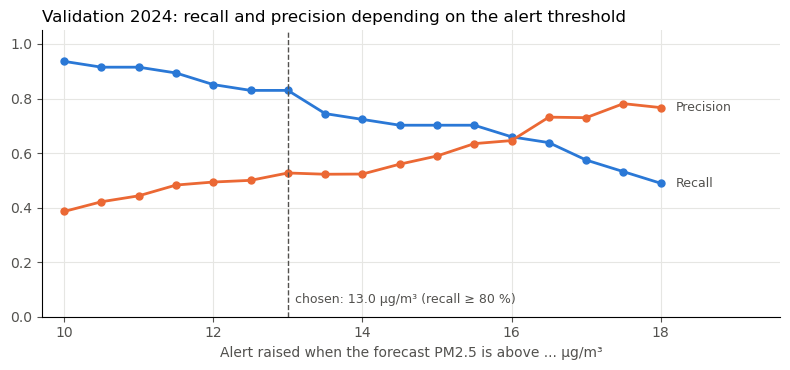

Alert threshold chosen on 2024: 13.0 µg/m³


,threshold,recall,precision,F1
0,10.0,0.94,0.39,0.55
1,10.5,0.91,0.42,0.58
2,11.0,0.91,0.44,0.60
3,11.5,0.89,0.48,0.63
4,12.0,0.85,0.49,0.62
5,12.5,0.83,0.50,0.62
6,13.0,0.83,0.53,0.64
7,13.5,0.74,0.52,0.61
8,14.0,0.72,0.52,0.61
9,14.5,0.70,0.56,0.62


In [9]:
valid_pred = forest.predict(X_valid)
thresholds = np.arange(10, 18.5, 0.5)
curve = pd.DataFrame([{"threshold": t,
                       "recall": recall_score(y_valid > WHO, valid_pred > t),
                       "precision": precision_score(y_valid > WHO, valid_pred > t),
                       "F1": f1_score(y_valid > WHO, valid_pred > t)} for t in thresholds])
# Public-health rule: catch at least 80 % of the exceedances (recall >= 0.8),
# and among the thresholds that do, keep the highest one (fewest false alarms).
MIN_RECALL = 0.80
ALERT_THRESHOLD = float(curve.loc[curve["recall"] >= MIN_RECALL, "threshold"].max())

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(curve["threshold"], curve["recall"], color=BLUE, linewidth=2, marker="o", markersize=5)
ax.plot(curve["threshold"], curve["precision"], color=ORANGE, linewidth=2, marker="o", markersize=5)
ax.text(curve["threshold"].iloc[-1] + 0.2, curve["recall"].iloc[-1], "Recall", color=GREY, va="center", fontsize=9)
ax.text(curve["threshold"].iloc[-1] + 0.2, curve["precision"].iloc[-1], "Precision", color=GREY, va="center", fontsize=9)
ax.axvline(ALERT_THRESHOLD, color=GREY, linestyle="--", linewidth=1)
ax.text(ALERT_THRESHOLD + 0.1, 0.05, f"chosen: {ALERT_THRESHOLD} µg/m³ (recall ≥ 80 %)", color=GREY, fontsize=9)
ax.set_xlim(thresholds.min() - 0.3, thresholds.max() + 1.6)
ax.set_ylim(0, 1.05)
ax.set_title("Validation 2024: recall and precision depending on the alert threshold")
ax.set_xlabel("Alert raised when the forecast PM2.5 is above ... µg/m³")
save("11_alert_threshold")
print("Alert threshold chosen on 2024:", ALERT_THRESHOLD, "µg/m³")
curve.round(2)

## 7. Final evaluation on 2025 (test set, used once)

Now that the model and the threshold are chosen, we **retrain the models on 2018-2024** (train + validation: more data, including the most recent year) and evaluate them **once** on 2025, a year none of the choices were based on.

In [10]:
train_full = train | valid
X_full, y_full = data.loc[train_full, FEATURES], data.loc[train_full, "target"]

linear_final = LinearRegression().fit(X_full, y_full)
forest_final = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1, **best_params).fit(X_full, y_full)
test_pred = forest_final.predict(X_test)

results_test = pd.DataFrame([
    evaluate("Persistence (baseline)", y_test, X_test["pm25_d"]),
    evaluate("Linear regression", y_test, linear_final.predict(X_test)),
    evaluate("Random Forest (threshold 15)", y_test, test_pred),
    evaluate(f"Random Forest (threshold {ALERT_THRESHOLD})", y_test, test_pred, threshold=ALERT_THRESHOLD),
]).set_index("model")
results_test.round(2)

,MAE,RMSE,R2,recall,precision,F1
model,,,,,,
Persistence (baseline),3.88,5.66,0.41,0.67,0.67,0.67
Linear regression,3.21,4.69,0.59,0.81,0.72,0.76
Random Forest (threshold 15),2.99,4.50,0.63,0.78,0.74,0.76
Random Forest (threshold 13.0),2.99,4.50,0.63,0.94,0.57,0.71


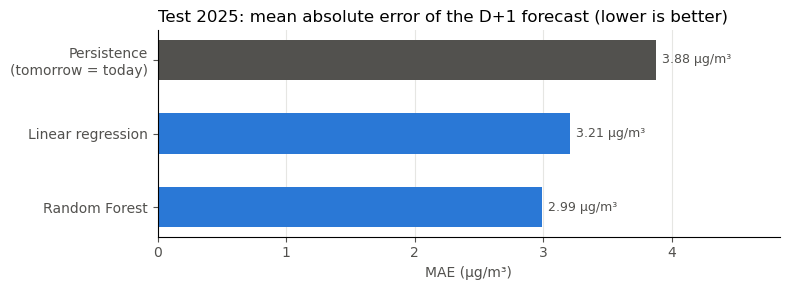

The Random Forest reduces the error of the baseline by 23%


In [11]:
fig, ax = plt.subplots(figsize=(8, 3))
mae = results_test["MAE"].iloc[:3]
colors = [GREY, BLUE, BLUE]
ax.barh(["Persistence\n(tomorrow = today)", "Linear regression", "Random Forest"], mae.values, color=colors, height=0.55)
for y, v in enumerate(mae.values):
    ax.text(v + 0.05, y, f"{v:.2f} µg/m³", va="center", color=GREY, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, mae.max() * 1.25)
ax.set_title("Test 2025: mean absolute error of the D+1 forecast (lower is better)")
ax.set_xlabel("MAE (µg/m³)")
ax.grid(axis="y", visible=False)
save("12_model_comparison")

gain = 1 - results_test.loc["Random Forest (threshold 15)", "MAE"] / results_test.loc["Persistence (baseline)", "MAE"]
print(f"The Random Forest reduces the error of the baseline by {gain:.0%}")

In [12]:
alert = test_pred > ALERT_THRESHOLD
matrix = confusion_matrix(y_test > WHO, alert)
pd.DataFrame(matrix,
             index=["Actual: below 15", "Actual: above 15"],
             columns=["Forecast: no alert", "Forecast: alert"])

,Forecast: no alert,Forecast: alert
Actual: below 15,170,46
Actual: above 15,4,60


**How to read the confusion matrix (2025):** the diagonal is the correct forecasts. Bottom-left = **missed exceedances** (the costly error for public health); top-right = **false alarms**.

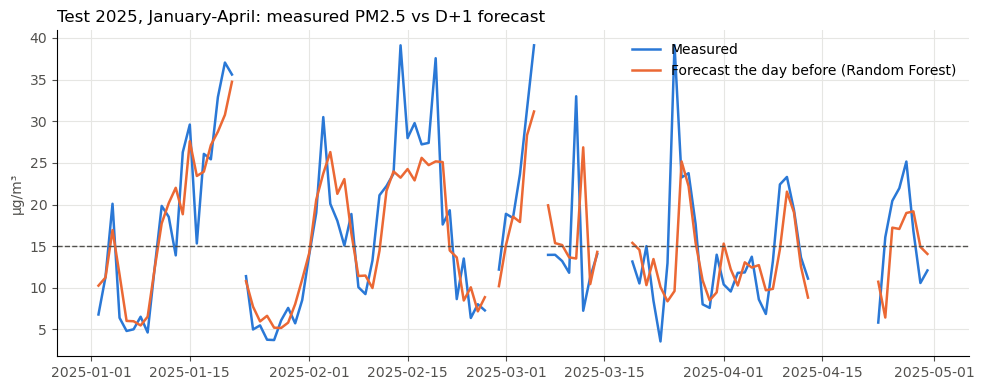

In [13]:
# Series indexed by the forecast day (D+1); asfreq("D") leaves gaps for missing days
# instead of drawing straight lines across them
forecast_day = data.loc[test, "date"] + pd.Timedelta(days=1)
measured = pd.Series(y_test.values, index=forecast_day).asfreq("D")["2025-01-01":"2025-04-30"]
forecast = pd.Series(test_pred, index=forecast_day).asfreq("D")["2025-01-01":"2025-04-30"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(measured.index, measured.values, color=BLUE, linewidth=1.8, label="Measured")
ax.plot(forecast.index, forecast.values, color=ORANGE, linewidth=1.8, label="Forecast the day before (Random Forest)")
ax.axhline(WHO, color=GREY, linestyle="--", linewidth=1)
ax.set_title("Test 2025, January-April: measured PM2.5 vs D+1 forecast")
ax.set_ylabel("µg/m³")
ax.legend(frameon=False, loc="upper right")
save("13_forecast_vs_measured")

**Reading** (the gaps are days where the measurement or a feature is missing): the forecast follows the rises and falls of pollution well. Like every regression model, it **smooths the peaks**: on the most polluted days it forecasts an exceedance, but a lower value than measured. It also reacts **one day late** on sudden starts of episodes, which depend on things the model does not see (e.g. pollution coming from other regions, agricultural spreading).

## 8. Which variables matter?

**Permutation importance:** we shuffle one feature at a time on the validation year and measure how much the error increases. The more the error increases, the more the model relies on that feature. (Caution: when two features carry the same information, e.g. `pm25_d` and `pm25_mean7`, their importance is shared between them.)

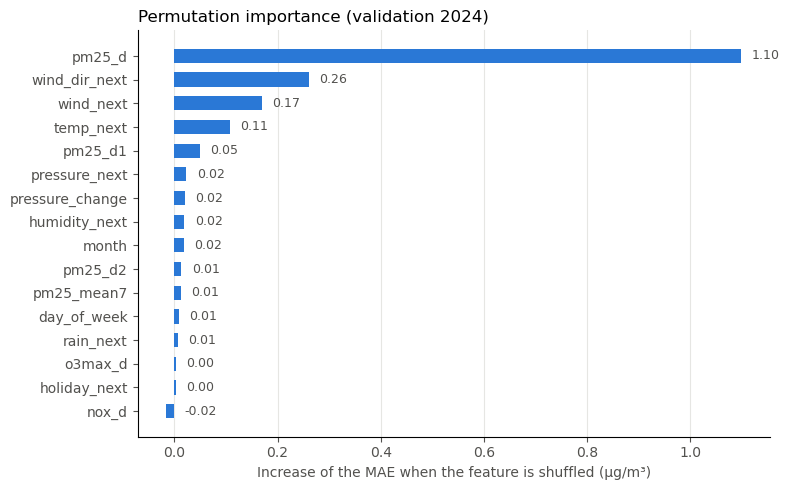

In [14]:
importance = permutation_importance(forest, X_valid, y_valid, scoring="neg_mean_absolute_error",
                                    n_repeats=10, random_state=42, n_jobs=-1)
importance = pd.Series(importance.importances_mean, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance.index, importance.values, color=BLUE, height=0.6)
for y, v in enumerate(importance.values):
    ax.text(max(v, 0) + 0.02, y, f"{v:.2f}", va="center", color=GREY, fontsize=9)
ax.set_title("Permutation importance (validation 2024)")
ax.set_xlabel("Increase of the MAE when the feature is shuffled (µg/m³)")
ax.grid(axis="y", visible=False)
save("14_feature_importance")

**Reading:**
- **Today's PM2.5** is by far the most important feature (persistence).
- Then comes **tomorrow's wind**: its **direction** first, then its speed. Winds from the north-east bring air that has crossed industrial and agricultural areas of northern Europe, while westerly winds bring clean air from the Atlantic. Temperature comes next.
- The calendar variables add little, and **NOx brings nothing more** once today's PM2.5 is known (their information overlaps).

This matches the EDA and the physics of pollution, which makes the model **explainable**: it has learned real mechanisms, not artefacts.

## 9. Demo on 2026

The model trained on 2018-2024 is applied to 2026, a period it has never seen.

In [15]:
X_demo, y_demo = data.loc[demo, FEATURES], data.loc[demo, "target"]
demo_pred = forest_final.predict(X_demo)
demo_result = pd.DataFrame([evaluate("Persistence (baseline)", y_demo, X_demo["pm25_d"]),
                            evaluate(f"Random Forest (threshold {ALERT_THRESHOLD})", y_demo, demo_pred,
                                     threshold=ALERT_THRESHOLD)]).set_index("model")
print(f"2026: {len(y_demo)} days, {int((y_demo > WHO).sum())} above the WHO guideline")
demo_result.round(2)

2026: 254 days, 41 above the WHO guideline


,MAE,RMSE,R2,recall,precision,F1
model,,,,,,
Persistence (baseline),3.34,4.92,0.45,0.56,0.56,0.56
Random Forest (threshold 13.0),2.73,4.03,0.63,0.76,0.53,0.62


In [16]:
# The forecasts as they would have been published during the March 2026 episode
last = data.loc[demo, ["date", "pm25_d", "target"]].copy()
last["forecast"] = demo_pred.round(1)
last = last[last["date"].between("2026-03-01", "2026-03-14")]
last["alert"] = np.where(last["forecast"] > ALERT_THRESHOLD, "ALERT", "-")
last = last.rename(columns={"date": "day D", "pm25_d": "PM2.5 on D", "target": "measured on D+1"})
last["day D"] = last["day D"].dt.date
last

,day D,PM2.5 on D,measured on D+1,forecast,alert
2336,2026-03-01,7.83,9.24,10.2,-
2337,2026-03-02,9.24,17.26,11.2,-
2338,2026-03-03,17.26,18.22,19.1,ALERT
2339,2026-03-04,18.22,21.12,18.5,ALERT
2340,2026-03-05,21.12,29.74,20.2,ALERT
2341,2026-03-06,29.74,46.78,27.5,ALERT
2342,2026-03-07,46.78,49.89,31.7,ALERT
2343,2026-03-08,49.89,20.52,25.5,ALERT
2344,2026-03-09,20.52,6.46,13.8,ALERT
2345,2026-03-10,6.46,6.82,7.3,-


**Reading:** for each evening D, the forecast for D+1 and what was really measured. An "ALERT" when the measured value stayed below 15 µg/m³ is a false alarm; a measured value above 15 without an alert is a missed exceedance.

## 10. Conclusions and limits

**Results**
- The Random Forest forecasts tomorrow's PM2.5 with a mean error of about **3 µg/m³**, clearly better than the persistence baseline and the linear regression, on a year it had never seen (2025) and again on 2026.
- With an alert threshold chosen on 2024 (recall first), it announces **about 9 exceedances out of 10 in 2025** the day before, at the cost of roughly one false alarm for each correct alert. In 2026 the recall is lower (about 3 out of 4): performance varies from one year to the next.
- The most useful information is **today's pollution** and **tomorrow's wind** (direction and speed), which matches the physics of pollution episodes.

**Limits**
- **Observed weather used as a forecast**: real weather forecasts have errors, so real-life performance would be a bit lower.
- **One station** (central Paris, background): the forecast is not valid for a street next to heavy traffic.
- **Station change in 2019** (PA04C → PA01H): a possible small break in the series.
- **Peaks are smoothed**: the model announces exceedances well but under-estimates the highest values.
- **External sources are not seen**: pollution transported from other regions, agricultural spreading, Saharan dust.

**Next steps**
- Use real **weather forecasts** (Météo-France forecast API) instead of observations.
- Add the **boundary-layer height** (the "lid" that traps pollution) and **regional background** stations (pollution coming from outside Paris).
- Try gradient boosting (e.g. XGBoost) and forecasting several days ahead (D+2, D+3).
- Serve the forecast through the Flask API (a `/forecast` endpoint).